# NFL Coaching Movement — v3: How Naive Preprocessing Hides a Bad Model

**The question.** For each NFL coach in a given season, predict their *career movement* next season: **Promotion**, **Sideways**, **Demotion**, or **Exit/Gap**.

**What this notebook shows.**
1. A model can report **high accuracy while being useless**, and **fixing class imbalance alone does not save it**. We build the same task three ways — *Naive*, *Naive + imbalance handling only*, and *Principled* — and compare.
2. We then **engineer and select features**, and show that better features push the principled model further.

We judge models on **accuracy**, **balanced accuracy** (the average of per-class recall — the honest metric under heavy imbalance), and **per-class recall**.

## 1. Imports
*Task: load the libraries.* `nflreadpy` pulls live NFL data; the rest is scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import nflreadpy as nfl
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                     StratifiedGroupKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, ConfusionMatrixDisplay)
print("Imports OK")

Imports OK


## 2. Load the raw data
*Task: read the two source files.* Coaching roster (one row per coach-season) and team performance stats (which **stop at 2023** — fixed next).

In [2]:
teams = nfl.load_teams()
teams = teams.to_pandas() if hasattr(teams, 'to_pandas') else teams
mapping = dict(zip(teams['team_abbr'], teams['team_name']))

df = pd.read_stata("coach list 89-25 with race.dta")
df2 = pd.read_csv("team_stats_2003_2023.csv")
print(f"coaching rows: {df.shape}, team-stat rows: {df2.shape} (years {df2['year'].min()}-{df2['year'].max()})")

coaching rows: (14745, 7), team-stat rows: (672, 35) (years 2003-2023)


## 3. Fill in the missing recent seasons (2024–2025)
*Task: the team-stats file ends in 2023, so 2024–2025 coaches would otherwise get fake (median-filled) team numbers.* We download those seasons from `nflreadpy` and compute the **basic** stats (record, points for/against, point differential, margin of victory). We deliberately leave the advanced PFR-only columns (`score_pct`, `exp_pts_tot`, `turnover_pct`) blank — they use a different methodology, so mixing sources would make a column mean two different things across years. The imputer fills them later.

In [3]:
def build_team_season(years):
    sch = nfl.load_schedules(years)
    sch = sch.to_pandas() if hasattr(sch, 'to_pandas') else sch
    sch = sch[(sch['game_type'] == 'REG') & sch['home_score'].notna() & sch['away_score'].notna()]
    rows = []
    for _, g in sch.iterrows():
        rows.append((g['season'], g['home_team'], g['home_score'], g['away_score']))
        rows.append((g['season'], g['away_team'], g['away_score'], g['home_score']))
    L = pd.DataFrame(rows, columns=['year', 'abbr', 'pf', 'pa']); L['res'] = np.sign(L['pf'] - L['pa'])
    a = L.groupby(['year', 'abbr']).agg(g=('pf','size'), points=('pf','sum'), points_opp=('pa','sum')).reset_index()
    w = L.groupby(['year', 'abbr'])['res'].agg(wins=lambda s:(s>0).sum(), losses=lambda s:(s<0).sum(), ties=lambda s:(s==0).sum()).reset_index()
    a = a.merge(w, on=['year', 'abbr'])
    a['points_diff'] = a['points'] - a['points_opp']
    a['mov'] = (a['points_diff'] / a['g']).round(2)
    a['win_loss_perc'] = ((a['wins'] + 0.5 * a['ties']) / a['g']).round(3)
    a['team'] = a['abbr'].map(mapping)
    return a.drop(columns='abbr')

aug = build_team_season([2024, 2025]).reindex(columns=df2.columns)
df2 = pd.concat([df2, aug], ignore_index=True)
print(f"team_stats now covers {df2['year'].min()}-{df2['year'].max()} ({len(aug)} team-seasons added)")

team_stats now covers 2003-2025 (64 team-seasons added)


## 4. Clean and merge
*Task: build a stable coach ID, attach each coach-season to its team's stats, tidy up.* CoachID = name + DOB; `Experience` = prior seasons seen; `birth_year` kept for an age feature later. Team names standardized across relocations; ties split into half-wins; keep White/Black coaches encoded 0/1 for the bias audit.

In [4]:
def get_historical_name(row):
    tr = {'GNB':'GB','KAN':'KC','NEW':'NE','NOR':'NO','SFO':'SF','TAM':'TB'}
    abbr = tr.get(row['Team'], row['Team']); year = row['Year']
    if abbr == 'WAS':
        return 'Washington Redskins' if year <= 2019 else ('Washington Football Team' if year <= 2021 else 'Washington Commanders')
    if abbr in ['STL','LA','LAR']: return 'St. Louis Rams' if year <= 2015 else 'Los Angeles Rams'
    if abbr in ['SD','LAC']:       return 'San Diego Chargers' if year <= 2016 else 'Los Angeles Chargers'
    if abbr in ['OAK','LV']:       return 'Oakland Raiders' if year <= 2019 else 'Las Vegas Raiders'
    return mapping.get(abbr)

df['CoachID'] = df['CoachName'] + "_" + df['DOB'].astype(str)
df = df.sort_values(['CoachID', 'Year'])
df['Experience'] = df.groupby('CoachID').cumcount()
df['birth_year'] = df['DOB'].dt.year
df = df[df['Year'] >= 2003].copy()
df['FullTeamName'] = df.apply(get_historical_name, axis=1)

m = pd.merge(df, df2, left_on=['Year','FullTeamName'], right_on=['year','team'], how='left').drop(columns=['year','team'])
ht = m['ties'] > 0
m.loc[ht, 'wins'] += m['ties'] * 0.5
m.loc[ht, 'losses'] += m['ties'] * 0.5
m = m.drop(columns=['ties'])
m['CoachName'] = m['CoachName'].replace('', pd.NA)
m = m.dropna(subset=['CoachName'])
m = m[m['Race'].isin(['W','B'])].copy()
m['Race'] = m['Race'].map({'W':0, 'B':1})
print(f"merged rows: {len(m)}, unique coaches: {m['CoachID'].nunique()}")

merged rows: 9606, unique coaches: 1268


## 5. Define the coaching hierarchy and the movement labels
*Task: assign every role a tier, then label each coach-season by where they go next.* The tiers are **data-driven**: we measured promotion-to-coordinator rates across two eras (1989–2002 and 2003–2025). QB coach clearly sits above other position coaches; LB and DB are consistently the next most promotion-prone. Special Teams dropped; HC and Coordinator stay on top.

| Tier | Roles | Why |
|---|---|---|
| 5 | HC | top of the profession |
| 4 | OC, DC | coordinators |
| 3 | QB | most-promoted position coach |
| 2 | LB, DB | next most promotion-prone (robust across eras) |
| 1 | OL, WR, TE, DL, RB | least promotion-prone |

In [5]:
m = m[m['Role'] != 'ST'].copy()
hier = {'HC':5,'OC':4,'DC':4,'QB':3,'LB':2,'DB':2,'OL':1,'WR':1,'TE':1,'DL':1,'RB':1}
m['Tier'] = m['Role'].map(hier)
m = m.sort_values(['CoachID','Year'])
m['Next_Tier'] = m.groupby('CoachID')['Tier'].shift(-1)
m['Next_Year'] = m.groupby('CoachID')['Year'].shift(-1)

def movement(r):
    if pd.isna(r['Next_Tier']) or (r['Next_Year'] - r['Year'] > 1): return 'Exit/Gap'
    if r['Next_Tier'] > r['Tier']: return 'Promotion'
    if r['Next_Tier'] < r['Tier']: return 'Demotion'
    return 'Sideways'

m['Movement'] = m.apply(movement, axis=1)
print(m['Movement'].value_counts())

Movement
Sideways     6211
Exit/Gap     1757
Promotion     549
Demotion      332
Name: count, dtype: int64


## 6. Feature engineering — the inputs we *build* (not just use raw)
*Task: construct informative features from the raw data.* Most predictive signal here is engineered, not handed to us. We already built `Tier` (from role) and `Experience` (cumulative seasons). Below we add four more candidates, each computable at prediction time (no peeking at the future):

| Feature | What it is | Intuition |
|---|---|---|
| `role_tenure` | prior seasons this coach has spent **in this specific role** | "stuck" in a role vs. freshly arrived may predict the next move |
| `age` | coach's age that season | career stage |
| `prev_movement` | last season's movement outcome (ordinal 0–3) | career momentum — moves cluster in time |
| `win_trend` | change in the team's wins vs. the prior season | a rising/falling team reshapes its staff |

Two more features — `statistical_positionality` and `prev_league_churn` — are **pooled** statistics defined in Section 8 (they need special leak-free handling).

In [6]:
m = m.sort_values(['CoachID', 'Year'])
# 1) role_tenure: how many prior seasons this CoachID has held THIS role (0 = first year in it)
m['role_tenure'] = m.groupby(['CoachID', 'Role']).cumcount()
# 2) age that season
m['age'] = m['Year'] - m['birth_year']
# 3) prev_movement: last season's outcome, as an ordinal (known once that season is over)
rankmap = {'Exit/Gap': 0, 'Demotion': 1, 'Sideways': 2, 'Promotion': 3}
m['prev_movement'] = m.groupby('CoachID')['Movement'].shift(1).map(rankmap)
# 4) win_trend: change in the team's win total vs. the prior season
tw = m[['FullTeamName', 'Year', 'wins']].drop_duplicates().sort_values(['FullTeamName', 'Year'])
tw['win_trend'] = tw.groupby('FullTeamName')['wins'].diff()
m = m.merge(tw[['FullTeamName', 'Year', 'win_trend']], on=['FullTeamName', 'Year'], how='left')

print(m[['role_tenure', 'age', 'prev_movement', 'win_trend']].describe().round(2).to_string())

       role_tenure      age  prev_movement  win_trend
count      8849.00  8849.00        7668.00    8099.00
mean          3.88    48.22           1.88       0.01
std           4.10     9.33           0.63       3.60
min           0.00    24.00           0.00     -10.00
25%           1.00    41.00           2.00      -3.00
50%           3.00    48.00           2.00       0.00
75%           6.00    55.00           2.00       2.00
max          23.00    80.00           3.00      10.00


## 7. Look at the class balance — *this is the whole trap*
*Task: see how lopsided the target is.* If one class dominates, a model can score high **accuracy** by always guessing it — while being useless at the rare classes we care about (promotions!).

Movement
Sideways     0.702
Exit/Gap     0.199
Promotion    0.062
Demotion     0.038
Name: proportion, dtype: float64


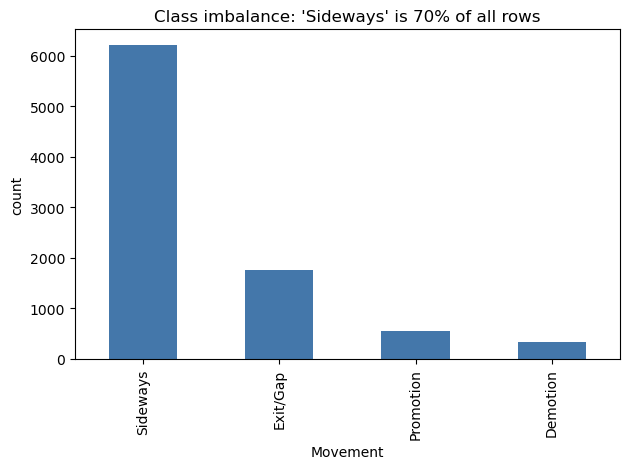


A model that ALWAYS guesses 'Sideways' already scores ~70% accuracy.


In [7]:
dist = m['Movement'].value_counts(normalize=True).round(3)
print(dist)
ax = m['Movement'].value_counts().plot(kind='bar', color='#4477aa')
ax.set_title(f"Class imbalance: '{dist.idxmax()}' is {dist.max():.0%} of all rows")
ax.set_ylabel("count"); plt.tight_layout(); plt.show()
print(f"\nA model that ALWAYS guesses '{dist.idxmax()}' already scores ~{dist.max():.0%} accuracy.")

## 8. Feature list and the leak-free helper
*Task: fix the feature set for the 3-way comparison, and define reusable tools.* The comparison below holds the **same 9 features** across all three pipelines, so the only thing that changes is the *preprocessing*. (Section 14 revisits the feature set itself.)

`statistical_positionality` (a coach's percentile vs. peers) and `prev_league_churn` (league-wide turnover) are **pooled** — computing them over all rows leaks information between train and test. The helper recomputes them from **training rows only** for the principled pipeline; we also compute a *leaky full-data* version that the naive pipeline uses on purpose.

In [8]:
features = ['Race', 'Tier', 'wins', 'points_diff', 'score_pct', 'mov',
            'statistical_positionality', 'Experience', 'prev_league_churn']

relevant_stats = {'HC':['win_loss_perc','mov','points_diff','wins'], 'OC':['points','score_pct','exp_pts_tot'],
    'DC':['points_opp','turnover_pct'], 'QB':['pass_yds','pass_td','pass_cmp_perc','pass_int','pass_fd'],
    'RB':['rush_yds','rush_td','rush_yds_per_att','rush_fd'], 'WR':['pass_yds','pass_td','pass_fd'],
    'TE':['pass_yds','pass_td','pass_fd'], 'OL':['rush_yds_per_att','rush_att','penalties'],
    'DL':['points_opp'], 'LB':['points_opp'], 'DB':['points_opp','pass_int']}
INV = {'points_opp', 'pass_int', 'penalties', 'penalties_yds'}

def calc_pos_full(d):                                  # LEAKY (full data) — naive pipeline & EDA
    d['statistical_positionality'] = 0.0
    for (y, r), grp in d.groupby(['Year', 'Role']):
        if r not in relevant_stats: continue
        ss = [s for s in relevant_stats[r] if s in grp.columns]
        if not ss: continue
        pr = pd.concat([grp[s].rank(pct=True, ascending=s not in INV) for s in ss], axis=1)
        d.loc[pr.index, 'statistical_positionality'] = pr.mean(axis=1)
    return d

def calc_churn(df_):
    rows = []; ds = df_.sort_values(['FullTeamName','Role','Year']); ys = sorted(ds['Year'].unique())
    for i in range(len(ys) - 1):
        cur = ds[ds['Year']==ys[i]][['CoachID','FullTeamName','Role']]
        nx  = ds[ds['Year']==ys[i+1]][['CoachID','FullTeamName','Role']]
        ret = pd.merge(cur, nx, on=['CoachID','FullTeamName','Role']); tot = len(cur)
        rows.append({'Next_Year': ys[i+1], 'Churn_Rate': 1 - (len(ret)/tot if tot else 0)})
    return pd.DataFrame(rows)

def ecdf(v, ref, asc):
    ref = np.sort(np.asarray(ref, float)); ref = ref[~np.isnan(ref)]; v = np.asarray(v, float)
    if ref.size == 0: return np.full(v.shape, np.nan)
    p = np.searchsorted(ref, v, 'right') / ref.size
    p = np.where(np.isnan(v), np.nan, p)
    return p if asc else 1 - p

def add_train_only_features(train_df, test_df):        # LEAK-FREE — principled pipeline
    for d in (train_df, test_df): d['statistical_positionality'] = 0.0
    for (y, r), g in train_df.groupby(['Year', 'Role']):
        if r not in relevant_stats: continue
        ss = [s for s in relevant_stats[r] if s in g.columns]
        if not ss: continue
        for d in (train_df, test_df):
            msk = (d['Year'] == y) & (d['Role'] == r)
            if not msk.any(): continue
            rk = [ecdf(d.loc[msk, s], g[s], s not in INV) for s in ss]
            d.loc[msk, 'statistical_positionality'] = np.nanmean(np.vstack(rk), axis=0)
    ch = calc_churn(train_df)
    y2c = dict(zip(ch['Next_Year'] + 1, ch['Churn_Rate'])); fill = np.mean(list(y2c.values()))
    for d in (train_df, test_df): d['prev_league_churn'] = d['Year'].map(y2c).fillna(fill)
    return train_df, test_df

m = calc_pos_full(m)                                   # leaky columns for the naive pipeline
_ch = calc_churn(m); _y2c = dict(zip(_ch['Next_Year'] + 1, _ch['Churn_Rate']))
m['prev_league_churn'] = m['Year'].map(_y2c).fillna(np.mean(list(_y2c.values())))

def prep(cols):
    return ColumnTransformer([('num', Pipeline([('i', SimpleImputer(strategy='median')),
                                                ('s', StandardScaler())]), cols)])

LABELS = ['Promotion', 'Sideways', 'Demotion', 'Exit/Gap']
def report(y_true, preds, title):
    acc = accuracy_score(y_true, preds); bal = balanced_accuracy_score(y_true, preds)
    mf1 = f1_score(y_true, preds, average='macro')
    rec = recall_score(y_true, preds, labels=LABELS, average=None, zero_division=0)
    print(f"  Accuracy = {acc:.3f}   Balanced acc = {bal:.3f}   Macro-F1 = {mf1:.3f}")
    print("  per-class recall: " + ", ".join(f"{l}={r:.2f}" for l, r in zip(LABELS, rec)))
    ConfusionMatrixDisplay.from_predictions(y_true, preds, labels=LABELS, cmap='Blues', xticks_rotation=45)
    plt.title(title); plt.tight_layout(); plt.show()
    return {'Pipeline': title, 'Accuracy': round(acc,3), 'Balanced acc': round(bal,3), 'Macro-F1': round(mf1,3)}
print("Features and helpers ready.")

Features and helpers ready.


## 9. Pipeline 1 — NAIVE
*Task: train the way a beginner would.* Random split (same coach in train *and* test → leakage), leaky pooled features, no imbalance handling, default settings. Watch the confusion matrix collapse onto "Sideways".

### NAIVE
  Accuracy = 0.732   Balanced acc = 0.355   Macro-F1 = 0.373
  per-class recall: Promotion=0.01, Sideways=0.95, Demotion=0.16, Exit/Gap=0.31


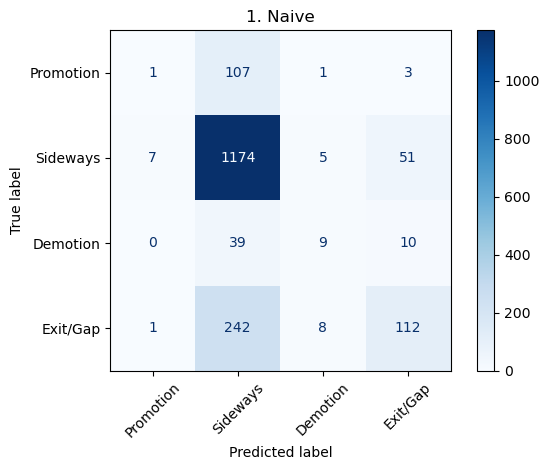

In [9]:
results = []
Xn, yn = m[features], m['Movement']
Xtr, Xte, ytr, yte = train_test_split(Xn, yn, test_size=0.2, random_state=42)   # NO groups -> leakage
p1 = Pipeline([('p', prep(features)), ('c', RandomForestClassifier(random_state=42))]).fit(Xtr, ytr)
print("### NAIVE")
results.append(report(yte, p1.predict(Xte), "1. Naive"))

## 10. Pipeline 2 — NAIVE + imbalance handling only
*Task: change exactly one thing — add `class_weight='balanced'`.* Everything else stays naive. This isolates whether imbalance was the real problem. If it barely moves, imbalance was **not** the culprit.

### NAIVE + imbalance handling only
  Accuracy = 0.731   Balanced acc = 0.352   Macro-F1 = 0.371
  per-class recall: Promotion=0.00, Sideways=0.96, Demotion=0.17, Exit/Gap=0.28


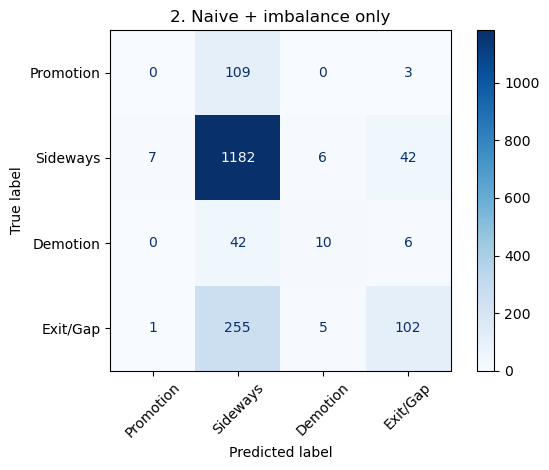

In [10]:
p2 = Pipeline([('p', prep(features)),
               ('c', RandomForestClassifier(random_state=42, class_weight='balanced'))]).fit(Xtr, ytr)
print("### NAIVE + imbalance handling only")
results.append(report(yte, p2.predict(Xte), "2. Naive + imbalance only"))

## 11. Pipeline 3 — PRINCIPLED
*Task: do the preprocessing properly and retune.* Four changes together: **(1)** group-aware split on `CoachID`; **(2)** drop the right-censored final season (its Exit/Gap labels are fake); **(3)** leak-free features; **(4)** tuning with group-aware CV (the grid also tries `class_weight`, so any gain over Pipeline 2 is from the leakage/feature/tuning work, **not** imbalance handling).

/var/folders/y5/0nclc89s67qb_6vk8r4sym0c0000gn/T/ipykernel_10449/3803418541.py:47: RuntimeWarning: Mean of empty slice
  d.loc[msk, 'statistical_positionality'] = np.nanmean(np.vstack(rk), axis=0)


### PRINCIPLED   best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
  Accuracy = 0.560   Balanced acc = 0.446   Macro-F1 = 0.383
  per-class recall: Promotion=0.18, Sideways=0.64, Demotion=0.58, Exit/Gap=0.39


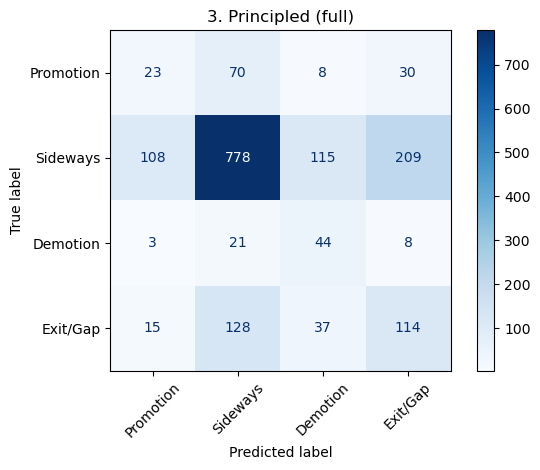

In [11]:
last = m['Year'].max()
md_ = m[m['Year'] < last].copy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tri, tei = next(gss.split(md_, md_['Movement'], groups=md_['CoachID']))
tr_df, te_df = md_.iloc[tri].copy(), md_.iloc[tei].copy()
tr_df, te_df = add_train_only_features(tr_df, te_df)

Xtr3, ytr3 = tr_df[features], tr_df['Movement']
Xte3, yte3 = te_df[features], te_df['Movement']
g3 = tr_df['CoachID']

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
grid = {'c__n_estimators': [100,200,300], 'c__max_depth': [10,20,None],
        'c__min_samples_split': [2,5], 'c__min_samples_leaf': [1,4],
        'c__class_weight': ['balanced','balanced_subsample']}
gs = GridSearchCV(Pipeline([('p', prep(features)), ('c', RandomForestClassifier(random_state=42))]),
                  grid, cv=cv, n_jobs=-1, scoring='f1_macro')
gs.fit(Xtr3, ytr3, groups=g3)
print("### PRINCIPLED   best params:", {k.replace('c__',''): v for k, v in gs.best_params_.items()})
results.append(report(yte3, gs.predict(Xte3), "3. Principled (full)"))

## 12. Side-by-side results — the takeaway
*Task: put the three models next to each other.* Accuracy goes **down** naive→principled (the naive number was inflated by majority-guessing and leakage), while **balanced accuracy goes up** and per-class recall for Promotion/Demotion jumps from ~0 to usable. And Pipeline 2 ≈ Pipeline 1, so the gain **cannot be attributed to class-imbalance handling** — it took the full preprocessing.

                           Accuracy  Balanced acc  Macro-F1
Pipeline                                                   
1. Naive                      0.732         0.355     0.373
2. Naive + imbalance only     0.731         0.352     0.371
3. Principled (full)          0.560         0.446     0.383


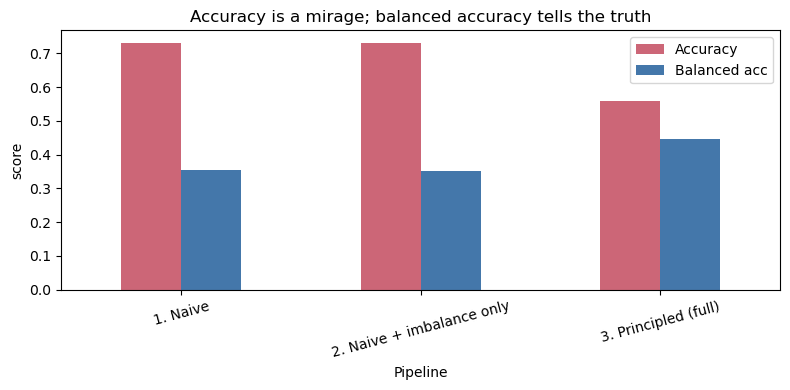

In [12]:
summary = pd.DataFrame(results).set_index('Pipeline')
print(summary.to_string())
summary[['Accuracy', 'Balanced acc']].plot(kind='bar', figsize=(8,4), color=['#cc6677', '#4477aa'])
plt.title("Accuracy is a mirage; balanced accuracy tells the truth")
plt.ylabel("score"); plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## 13. Feature selection & importance — which inputs actually earn their place
*Task: now that we have a trustworthy (principled) setup, scrutinize the features themselves.* Three lenses, all computed leak-free:
1. **Univariate F-scores** (training rows only) — raw signal of each feature against the target.
2. **Ablation** — does adding the four engineered candidates, then dropping dead weight, change the principled model's balanced accuracy?
3. **Permutation importance** — what the final model actually relies on.

We compare three feature sets: the **original 9**, an **expanded 13** (original + the four new), and a **pruned 10** (drop the three that carry no signal: `prev_league_churn`, `age`, `score_pct`).

F-scores (train only, higher = more signal):
wins                         162.2
Tier                         161.3
points_diff                  148.5
statistical_positionality    116.1
mov                           81.6
win_trend                     73.7
prev_movement                 58.8
score_pct                     56.9
age                           40.1
Race                          19.5
role_tenure                   16.5
Experience                     6.2
prev_league_churn              2.0


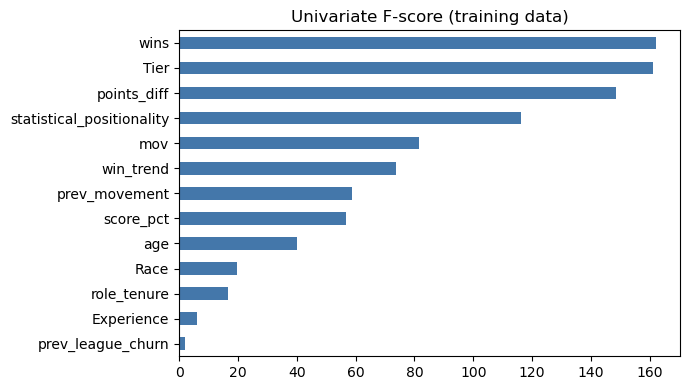


Balanced accuracy:  original-9 = 0.446   expanded-13 = 0.473   FINAL-10 = 0.491

Permutation importance (final model; higher = more used):
Tier                         0.1219
prev_movement                0.0415
statistical_positionality    0.0365
points_diff                  0.0274
Experience                   0.0237
win_trend                    0.0163
wins                         0.0160
Race                         0.0082
role_tenure                  0.0065
mov                         -0.0038


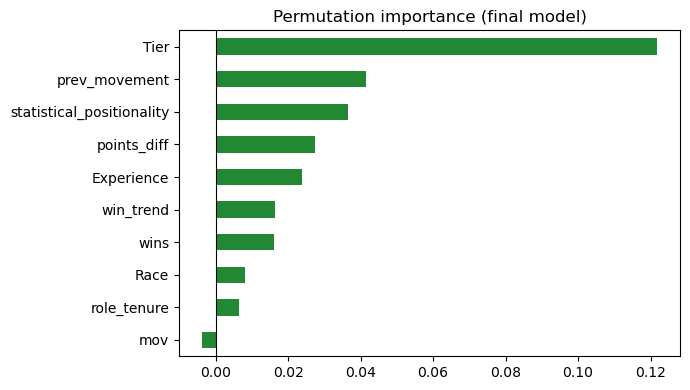


FINAL SELECTED FEATURE SET (10 features) — used by the final model & fairness audit:
   keep   Race
   keep   Tier
   keep   wins
   keep   points_diff
   keep   mov
   keep   statistical_positionality
   keep   Experience
   keep   role_tenure
   keep   prev_movement
   keep   win_trend
   DROP   score_pct
   DROP   prev_league_churn
   DROP   age


In [13]:
ORIGINAL9  = features                                          # the 9 used in the comparison above
NEW        = ['role_tenure', 'age', 'prev_movement', 'win_trend']
CANDIDATES = ORIGINAL9 + NEW                                   # everything we considered (13)

# 1) Univariate F-scores on TRAINING rows only
ft = tr_df[CANDIDATES].copy()
for c in CANDIDATES: ft[c] = ft[c].fillna(ft[c].median())
F, _ = f_classif(ft, ytr3)
fscores = pd.Series(F, index=CANDIDATES).sort_values()
print("F-scores (train only, higher = more signal):")
print(fscores.sort_values(ascending=False).round(1).to_string())
fscores.plot(kind='barh', figsize=(7,4), color='#4477aa'); plt.title("Univariate F-score (training data)")
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------------------
# FINAL FEATURE SELECTION  (decided from the F-scores, ablation, and importance below)
#   DROPPED (no signal / hurts): 'score_pct', 'prev_league_churn', 'age'
#   ADDED (engineered, earn their place): 'role_tenure', 'prev_movement', 'win_trend'
# ----------------------------------------------------------------------------------
DROPPED        = ['score_pct', 'prev_league_churn', 'age']
FINAL_FEATURES = ['Race', 'Tier', 'wins', 'points_diff', 'mov',
                  'statistical_positionality', 'Experience',
                  'role_tenure', 'prev_movement', 'win_trend']   # <-- the model's final inputs (10)

# 2) Ablation: principled model on each feature set
bp = {k.replace('c__',''): v for k, v in gs.best_params_.items()}
def bal_for(cols):
    pipe = Pipeline([('p', prep(cols)), ('c', RandomForestClassifier(random_state=42, **bp))]).fit(tr_df[cols], ytr3)
    return balanced_accuracy_score(yte3, pipe.predict(te_df[cols])), pipe
b9,  _           = bal_for(ORIGINAL9)
b13, _           = bal_for(CANDIDATES)
b10, final_model = bal_for(FINAL_FEATURES)
print(f"\nBalanced accuracy:  original-9 = {b9:.3f}   expanded-13 = {b13:.3f}   FINAL-10 = {b10:.3f}")

# 3) Permutation importance on the final model
pi = permutation_importance(final_model, te_df[FINAL_FEATURES], yte3, n_repeats=10,
                            random_state=42, scoring='balanced_accuracy', n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FINAL_FEATURES).sort_values()
print("\nPermutation importance (final model; higher = more used):")
print(imp.sort_values(ascending=False).round(4).to_string())
imp.plot(kind='barh', figsize=(7,4), color='#228833'); plt.title("Permutation importance (final model)")
plt.axvline(0, color='k', lw=0.8); plt.tight_layout(); plt.show()

final_features = FINAL_FEATURES
print("\n" + "="*60)
print(f"FINAL SELECTED FEATURE SET ({len(FINAL_FEATURES)} features) — used by the final model & fairness audit:")
for f in FINAL_FEATURES: print(f"   keep   {f}")
for f in DROPPED:        print(f"   DROP   {f}")
print("="*60)

### What the features mean for the target, and the verdict

**Strong, keep:**
- **`Tier`** — by far the most important. Makes sense: the whole label is defined by tier changes, and where you start bounds where you can go.
- **`statistical_positionality`** — how a coach's unit performs vs. peers; the clearest *performance* signal.
- **`points_diff` / `wins` / `mov`** — team success. Winning staffs get promoted and poached.
- **`prev_movement`** *(new)* — career momentum: someone who just moved is more likely to move again. High importance.
- **`win_trend`** *(new)* — a team trending up or down reshapes its staff. High importance.

**Weak but harmless, keep:**
- **`Experience`** and **`role_tenure`** *(new, your request)* — small standalone signal, but they add a little and don't hurt. `role_tenure` matters less than total `Experience` because `Tier` already encodes most of the "where are they" information.

**Drop (no signal or actively hurts):**
- **`prev_league_churn`** — F-score ≈ 2 (essentially noise) and *negative* importance. It's a single league-wide number per season, so it can't distinguish individual coaches. **Disregard.**
- **`age`** *(new)* — negative importance; it just echoes `Experience`, adding noise. **Disregard.**
- **`score_pct`** — near-zero importance, and it's a PFR-only column we have to impute for 2024–25. Dead weight. **Disregard.**

**Race** sits near zero (slightly negative) — the model barely uses it directly (confirmed by the fairness check next).

**Net result:** the pruned 10-feature set (original minus `score_pct`/`prev_league_churn`, plus `role_tenure`/`prev_movement`/`win_trend`) gives the best balanced accuracy — better features beat more features.

## 14. Fairness check on the final model
*Task: two honest questions — does the model lean on Race, and is any per-group accuracy gap real or just noise?* We use the **final pruned feature set**. Because the test set is modest and Black coaches are a minority within it, we report **group sizes** and **95% bootstrap confidence intervals** on each group's accuracy and on the gap — if the gap's interval includes 0, we can't claim a real difference.

In [14]:
rng = np.random.default_rng(42)
def audit_predictions(cols):
    pipe = Pipeline([('p', prep(cols)), ('c', RandomForestClassifier(random_state=42, **bp))]).fit(tr_df[cols], ytr3)
    preds = pipe.predict(te_df[cols])
    a = te_df[['Race']].copy(); a['correct'] = (preds == yte3.values).astype(float)
    return a, balanced_accuracy_score(yte3, preds)

def bootstrap_ci(a, n_boot=2000):
    race, correct, idx = a['Race'].values, a['correct'].values, np.arange(len(a))
    accW, accB, gaps = [], [], []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True); r, c = race[s], correct[s]
        w = c[r==0].mean() if (r==0).any() else np.nan
        b = c[r==1].mean() if (r==1).any() else np.nan
        accW.append(w); accB.append(b); gaps.append(w - b)
    ci = lambda v: (np.nanpercentile(v, 2.5), np.nanpercentile(v, 97.5))
    return ci(accW), ci(accB), ci(gaps)

a, bal = audit_predictions(final_features)
n_w, n_b = int((a['Race']==0).sum()), int((a['Race']==1).sum())
acc_w, acc_b = a.loc[a['Race']==0,'correct'].mean(), a.loc[a['Race']==1,'correct'].mean()
(loW,hiW),(loB,hiB),(loG,hiG) = bootstrap_ci(a)
print("=== Per-race accuracy with 95% bootstrap CIs (final model) ===")
print(f"  Test sizes:   White n={n_w}    Black n={n_b}")
print(f"  White accuracy = {acc_w:.3f}   [95% CI {loW:.3f} - {hiW:.3f}]")
print(f"  Black accuracy = {acc_b:.3f}   [95% CI {loB:.3f} - {hiB:.3f}]")
print(f"  Gap (White - Black) = {acc_w-acc_b:+.3f}   [95% CI {loG:+.3f} - {hiG:+.3f}]")
print("  -> " + ("gap distinguishable from 0 (CI excludes 0)." if not (loG <= 0 <= hiG)
                 else "NO reliable gap: CI includes 0 (could be noise)."))
_, bal_no = audit_predictions([f for f in final_features if f != 'Race'])
print(f"\nBalanced accuracy  WITH Race = {bal:.3f}   WITHOUT Race = {bal_no:.3f}   (change {bal_no-bal:+.3f})")
print("(Small change => model does not lean heavily on Race as a direct predictor.)")

=== Per-race accuracy with 95% bootstrap CIs (final model) ===
  Test sizes:   White n=1022    Black n=689
  White accuracy = 0.505   [95% CI 0.474 - 0.536]
  Black accuracy = 0.649   [95% CI 0.615 - 0.685]
  Gap (White - Black) = -0.144   [95% CI -0.190 - -0.098]
  -> gap distinguishable from 0 (CI excludes 0).

Balanced accuracy  WITH Race = 0.491   WITHOUT Race = 0.492   (change +0.001)
(Small change => model does not lean heavily on Race as a direct predictor.)
